# Enfoques básicos para la detección de cambio semánticos

**Resumen del conjunto de datos**

* Duración: 15 periodos parlamentarios - 127 a 141
* Períodos: 5 períodos parlamentarios
* Total palabras: 27806
* Vocabulario: 3221
* Dominio: Proyectos de ley de salud argentina (iniciativas)


El problema consiste en cuantificar el cambio lingüístico en el significado y el uso de las palabras a lo largo del tiempo. Dado un corpus temporal C, creado durante un lapso de tiempo S, lo dividimos en n instantáneas Ct, cada una con una duración P. Construimos un vocabulario común V mediante la intersección de los diccionarios de palabras que
aparecen en todas las instantáneas (es decir, rastreamos el mismo conjunto de palabras a lo largo del tiempo). Esto elimina ejemplos triviales de cambio en el uso de las palabras que aparecen o desaparecen en el corpus.
Para modelar la evolución de palabras, construimos una serie temporal T(w) para cada palabra w perteneciente a V. Cada punto Tt(w) corresponde a la información estadística extraída de la instantánea del corpus Ct , que refleja el uso de w. 

Paper: 2014 - Statistically Significant Detection of Linguistic Change . Kulkarni et al.. 
file:///C:/Users/Usuario/iamas_iniciativasleg_salud/papers/Statistically%20Significant%20Detection%20of%20Linguistic%20Chang.pdf

In [1]:
# Importar librerias

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

from tqdm import tqdm
tqdm.pandas()

In [2]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [3]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (2848, 12)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 12)


In [4]:
# LECTURA OBJETO PARA DETECTAR CAMBIOS SEMANTICOS
with open(RESULTADOS_DIR + 'periodo_5anios_df.pkl', 'rb') as file: 
    PER5anios_df = pickle.load(file)

In [5]:
PER5anios_df.head(1)

Periodo_5anios  \
0            2009   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [6]:
freqs_list = []
for anios5 in PER5anios_df['Periodo_5anios'].to_list():

    print(anios5)
    subdf = PER5anios_df.loc[(PER5anios_df['Periodo_5anios']==anios5),]
    subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")                                 
    
    freqs = Counter()
    subdf['Título normalizado'].apply(lambda x: freqs.update(x.split())) # cualquier espacio.
    total_number = sum(freqs.values())
    print('Número total de tokens:', total_number)

    freqs_df = pd.DataFrame.from_dict(freqs, orient='index',
                                      columns=['Frecuencia'])
    freqs_df = freqs_df.reset_index()

    freqs_df = freqs_df.rename(columns={'index': 'Palabra'})
    mask = (freqs_df['Palabra'].str.len() > 1)
    print(freqs_df.shape)
    freqs_df = freqs_df.loc[mask]
    print(freqs_df.shape)
    print('Entradas removidas de 1 carácter.')
    print('Cantidad de tokens únicos:', freqs_df.shape[0])

    freqs_df = freqs_df.sort_values('Frecuencia').reset_index(drop=True)

    freqs_df['Frecuencia relativa'] = freqs_df['Frecuencia'] / total_number

    freqs_df['Período'] = str(anios5)
    
    freqs_list.append(freqs_df)
    

2009
Número total de tokens: 7872
(1717, 2)
(1717, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1717
2014
Número total de tokens: 9731
(1969, 2)
(1969, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1969
2019
Número total de tokens: 10203
(1876, 2)
(1876, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1876


C:\Users\Usuario\AppData\Local\Temp\ipykernel_55160\4042035746.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_55160\4042035746.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_55160\4042035746.py:6: SettingWithCopyWarning: 
A value is trying to be set on

### Método de frecuencia

La forma más inmediata de detectar secuencias de eventos discretos es a través de su cambio de frecuencia. Por lo tanto, los métodos basados en la frecuencia son muy populares e incluyen herramientas como Google Trends y Google Books Ngram Corpus, ambos utilizados en investigación para predecir cambios económicos y de salud pública [8, 9]. Dicho análisis depende de la búsqueda de palabras clave en corpus indexados. Los métodos basados ​​en la frecuencia pueden capturar cambios lingüísticos, ya que los cambios de frecuencia pueden corresponder a la adquisición o pérdida de significado de las palabras. Aunque rudimentario, este método es fácil de implementar. Monitoreamos el cambio en la probabilidad de aparición de una palabra a lo largo del tiempo. Calculamos para cada corpus de instantánea temporal Ct, un modelo lingüístico unigrama. Específicamente, construimos la serie temporal para una palabra w de la siguiente manera:

* Tt(w) = log #(w ∈ Ct)/ |Ct| 

donde #(w ∈ Ct) es el número de ocurrencias de la palabra w en la instantánea del corpus Ct.

In [7]:
freqs_df = pd.concat(freqs_list) # Dataframe de frecuecias
#  natural logarithm (base e)
freqs_df['t(w)'] = np.log(freqs_df['Frecuencia relativa'])
freqs_df = freqs_df.sort_values('t(w)', ascending=False)

In [8]:
#### top 10 
freqs_df.head(10)


,Palabra,Frecuencia,Frecuencia relativa,Período,t(w)
1875,nacional,360,0.035284,2019,-3.344333
1968,nacional,268,0.027541,2014,-3.592085
1716,nacional,208,0.026423,2009,-3.633529
1874,creacion,251,0.024601,2019,-3.704984
1967,creacion,220,0.022608,2014,-3.789444
1966,regimen,203,0.020861,2014,-3.869866
1873,programa,211,0.020680,2019,-3.878579
1715,creacion,157,0.019944,2009,-3.914822
1872,salud,195,0.019112,2019,-3.957438
1871,regimen,176,0.017250,2019,-4.059953


## 1 - Determinar vocabulario común entre los períodos

In [9]:
Vocab_periodo_df =  pd.pivot_table(freqs_df, values=['t(w)'], columns=['Período'],
                      index=['Palabra']).reset_index()

Vocab_periodo_df.columns = [col[1] if col[1] else col[0] for col in Vocab_periodo_df.columns]
Vocab_periodo_df.fillna(0, inplace=True) # Rellenar valores faltantes con 0
Vocab_periodo_df.describe()

,2009,2014,2019
count,3221.000000,3221.000000,3221.000000
mean,-4.371167,-5.102145,-4.867040
std,4.153869,4.141271,4.194146
min,-8.971067,-9.183072,-9.230437
25%,-8.971067,-9.183072,-8.537290
50%,-6.332010,-7.573634,-7.284527
75%,0.000000,0.000000,0.000000
max,0.000000,0.000000,0.000000


In [10]:
# Vocabulario común
vocab_comun_df = Vocab_periodo_df[(Vocab_periodo_df['2009']!=0) & (Vocab_periodo_df['2014']!=0) & (Vocab_periodo_df['2019']!=0)]
display(vocab_comun_df.head())
display(vocab_comun_df.describe()) ## 772 vocbulario común es correcto - ver notebook 3.3

,Palabra,2009,2014,2019
12,abril,-7.025157,-7.796778,-8.131825
20,acceder,-7.361630,-9.183072,-9.230437
21,accesibilidad,-8.277920,-7.573634,-7.844143
23,acceso,-6.263017,-6.138550,-5.646918
25,accidente,-7.361630,-7.237162,-7.844143


,2009,2014,2019
count,772.000000,772.000000,772.000000
mean,-7.646945,-7.633653,-7.766203
std,1.125504,1.106071,1.164266
min,-8.971067,-9.183072,-9.230437
25%,-8.277920,-8.489925,-8.537290
50%,-7.872455,-7.796778,-7.844143
75%,-7.025157,-6.985847,-7.033212
max,-3.633529,-3.592085,-3.344333


¿El término "muerte_subita" tiene presencia en los tres períodos a comparar?¿Cómo es t(w) en la palabra muerte súbita?

In [11]:
Vocab_periodo_df[Vocab_periodo_df['Palabra']=='muerte_subita']

,Palabra,2009,2014,2019
2038,muerte_subita,-8.27792,-7.796778,-7.844143


Palabras asociadas a muerte súbita (seleccionadas): 'desfibrilador','desfibracion','cardiovascular','cardioasistido','dea','dispositivo', 'muerte','vida','vivir','morir','capacitacion','capacitar','capacita', 'emergencia','supervivencia','reanimacion','prevencion','incidencia','deportivo'


In [12]:
ms_list = ['desfibrilador','desfibracion','cardiovascular','cardioasistido','dea','dispositivo', 'muerte','vida','vivir','morir','capacitacion','capacitar','capacita', 'emergencia','supervivencia','reanimacion','prevencion','incidencia','deportivo']
print("Cantidad de palabras de la lista ms:",len(ms_list))
print("Palabras encontradas: ", Vocab_periodo_df[Vocab_periodo_df['Palabra'].isin(ms_list)].shape[0])
Vocab_periodo_df[Vocab_periodo_df['Palabra'].isin(ms_list)] # 14 palabras ojo con morir, vivir,incidencia y cardiovascular

Cantidad de palabras de la lista ms: 19
Palabras encontradas:  14


,Palabra,2009,2014,2019
431,capacitacion,-7.361630,-6.544015,-5.863141
453,cardiovascular,0.000000,-8.489925,-8.131825
807,dea,-8.971067,-8.084460,-7.620999
858,deportivo,-7.179308,-6.618123,-6.927852
891,desfibrilador,-7.025157,-7.103630,-7.620999
973,dispositivo,-7.872455,-7.796778,-7.620999
1064,emergencia,-4.843933,-5.311871,-5.056050
1591,incidencia,0.000000,-8.084460,-9.230437
2026,morir,0.000000,0.000000,-8.131825
2037,muerte,-6.891626,-8.084460,-7.150996


De las 14 palabras ojo con morir, vivir,incidencia y cardiovascular.
Solo 10 palabras aparecen en vocabulario común en los tres períodos

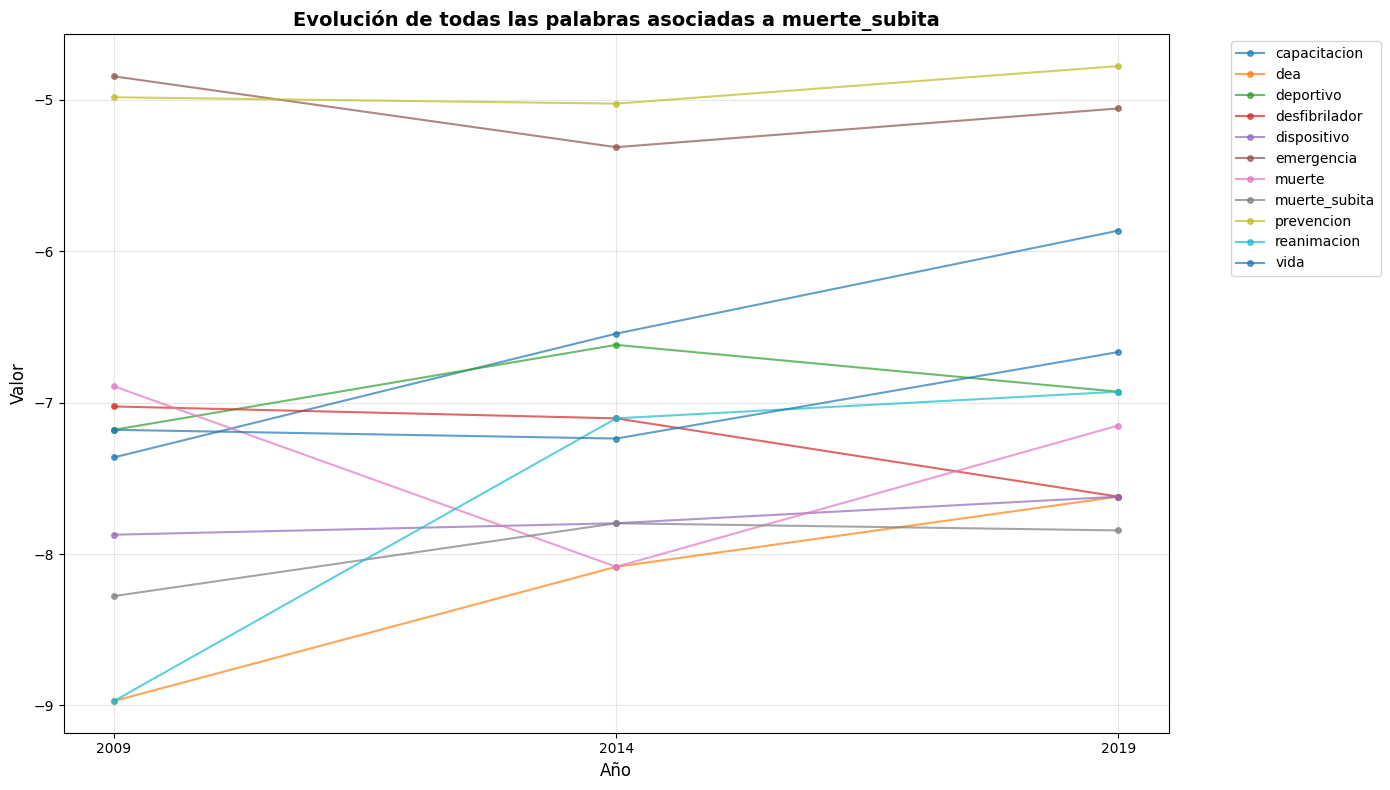

In [13]:
# Gráfico con todas las palabras (útil si tienes pocas palabras)
plt.figure(figsize=(14, 8))
df = vocab_comun_df[vocab_comun_df['Palabra'].isin(ms_list+['muerte_subita'])]


for idx, fila in df.iterrows():
    palabra = fila['Palabra']
    años = ['2009', '2014', '2019']
    valores = [fila['2009'], fila['2014'], fila['2019']]
    
    plt.plot(años, valores, marker='o', linewidth=1.5, markersize=4, 
             label=palabra, alpha=0.7)

plt.title('Evolución de todas las palabras asociadas a muerte_subita', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.grid(True, alpha=0.3)
# Si hay muchas palabras, mejor no mostrar leyenda o usar interactividad
if len(df) <= 12:
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    plt.legend().set_visible(False)  # Ocultar leyenda si hay muchas palabras

plt.tight_layout()
plt.show()

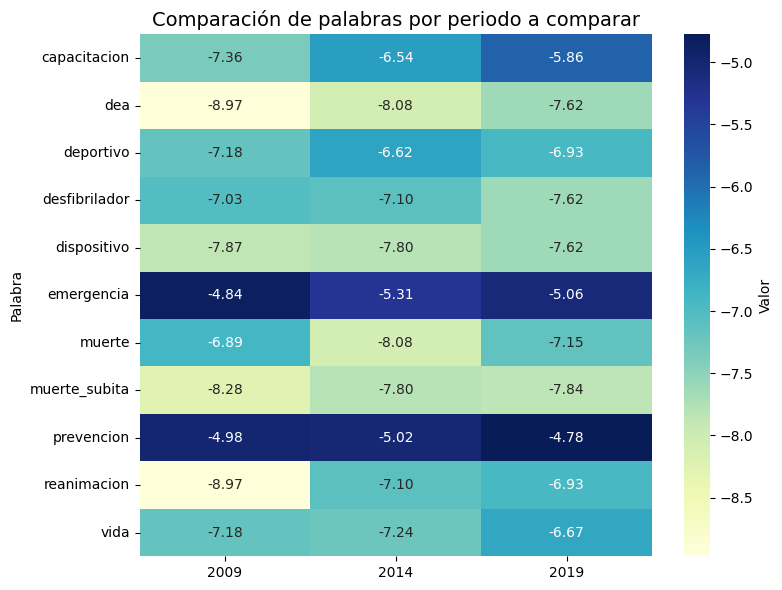

In [14]:
plt.figure(figsize=(8, 6))

# Seleccionar algunas palabras para comparar
palabras_ejemplo = ms_list+['muerte_subita']
datos_heatmap = df[df['Palabra'].isin(palabras_ejemplo)].set_index('Palabra')

sns.heatmap(datos_heatmap, annot=True, cmap='YlGnBu', fmt='.2f',
            cbar_kws={'label': 'Valor'})
plt.title('Comparación de palabras por periodo a comparar', fontsize=14)
plt.tight_layout()
plt.show()


Se observan posibles cambios para 'capacitacion', 'dea','deportivo','desfibrilador', 'muerte', 'vida'. Muerte_subita pareciera que no tiene cambio.

## 2- Detección de punto de cambio 

Dada una serie temporal de una palabra T (w), construida utilizando método de frecuencia buscamos determinar si la palabra cambió significativamente y, de ser así, estimar el punto de cambio.
Tener en cuenta W. A. Taylor. Change-point analysis: A powerful new
tool for detecting changes, 2000.

#### Algoritmo
* Dada una serie temporal de una palabra T(w), primero la normalizamos. Luego, la transformamos en una puntuación Z. Donde Zi(w) es la puntuación z de la serie temporal para la palabra w en el instante de tiempo i. En nuestro caso tenemos tres puntos de tiempo al haber tres perídos a comparar. En nuestro ejemplo n=3.
* Modelamos la serie temporal Z(w) mediante un modelo de desplazamiento de la media [40]. 
Sea S = Z1(w), Z2(w), ..., Zn(w) la serie temporal. Modelamos S como el resultado de un proceso estocástico donde cada Si se puede describir como Si = μi + errori, donde μi es la media y el error i es el error aleatorio en el instante i. También asumimos que los errores i son independientes con media 0. Generalmente, μi = μi−1, excepto en algunos puntos que son puntos de cambio.

* Con base en el modelo anterior, definimos el desplazamiento de la media de una serie temporal general S de la siguiente manera: Esto corresponde al cálculo del desplazamiento de la media entre dos partes de la serie temporal pivotadas en el punto temporal j. De este modo, los puntos de cambio pueden identificarse detectando desplazamientos significativos en la media. Dada una serie temporal normalizada Z(w), calculamos la serie de desplazamiento de la media K(Z(w)) (Línea 2).
  
* Para estimar la significancia estadística de observar un desplazamiento de la media en el punto temporal j, utilizamos el método bootstrap [14] ( Líneas 3-10) bajo la hipótesis nula de que no hay cambio en la media. En particular, establecemos la significancia estadística obteniendo primero B (típicamente B = 1000) muestras bootstrap obtenidas permutando Z(w) (Líneas 3-10). En segundo lugar, para cada muestra bootstrap P, calculamos K(P) para obtener su correspondiente estadístico bootstrap y estimamos la significancia estadística (valor p) de observar el cambio de media en el tiempo i en comparación con la distribución N U LL (líneas 8-10). Finalmente, estimamos el punto de cambio considerando el punto temporal j con el valor p mínimo (descrito en [39]). Si bien este método detecta cambios significativos en la media de la serie temporal, no tiene en cuenta la magnitud del cambio en términos de puntuaciones Z.
* Extendemos este enfoque para obtener palabras que cambiaron significativamente en comparación con otras palabras, considerando solo aquellos puntos temporales donde la puntuación Z supera un umbral γ definido por el usuario (normalmente establecemos γ en 1,75). A continuación, estimamos el punto de cambio como el punto temporal con el valor p mínimo, exactamente como se indicó anteriormente (líneas 11-14).

* Hipótesis nula (H₀): “No hay cambio en la media de la serie temporal Z(w)”. → Es decir, cualquier variación que vemos es puro azar.
* bootstrapping con permutación: Toman la serie temporal normalizada de una palabra z(w). La reordenan aleatoriamente (permutación).
Vuelven a calcular la serie de mean shift k(z(w)) para la permutación. Repiten esto B veces (generalmente B = 1000).
* ¿Por qué permutar? Si reordenamos aleatoriamente, rompemos cualquier estructura temporal real.
→ Así generamos muestras que representan el escenario de H₀ (no hay cambio real).
* Construcción de la distribución nula:
Al hacer esto 1000 veces, obtenemos una distribución de valores K bajo H₀. Esa es la referencia contra la cual vamos a comparar el valor observado en los datos reales.
* Cálculo del p-value: Mientras más chico sea el p-value, más evidencia de que el cambio es real y no azar.


In [15]:
import numpy as np

# ---------------------------------------------------------
# 1. Normalización de la serie T(w) en Z-scores
# ---------------------------------------------------------
def normalize_series(T_w, mu_i, var_i):
    """
    Normaliza la serie T(w) en z-scores según la fórmula del paper.
    
    T : array con valores T(w) en cada periodo parlamentario (ej. [0.3, 0.5, 0.8])
    all_words_T : matriz (vocab_size x n_periodos) con las series de todas las palabras,
                  usada para calcular μ y Var en cada periodo
    
    Retorna:
        Z : array de z-scores para la palabra w
    """
    n = len(T_w)
    Z = np.zeros(n)
    for i in range(n):  # i = periodo (snapshot temporal)
        Z[i] = (T_w[i] - mu_i[i]) / var_i[i]                # Zi(w) = (Ti(w)-μi) / σi
    return Z


# ---------------------------------------------------------
# 2. Mean shift K(S, j)
# ---------------------------------------------------------
def K_mean_shift(S, j):
    """
    Calcula el mean shift en el punto de corte j.
    j divide la serie en [0..j-1] y [j..n-1].
    
    S : serie temporal ya normalizada Z(w)
    j : punto de corte candidato (1..n-1)
    
    Retorna:
        diferencia de medias entre derecha e izquierda
    """
    l = len(S)
    left = np.mean(S[:j])     # (1/j) * sum_{k=1}^j S_k
    right = np.mean(S[j:])    # (1/(l-j)) * sum_{k=j+1}^l S_k
    return right - left       # K(S, j)


# ---------------------------------------------------------
# 3. Bootstrapping para obtener muestras bajo la hipótesis nula
# ---------------------------------------------------------
def bootstrap_samples(Z, B=10000):
    """
    Genera B permutaciones de la serie Z(w).
    Esto modela la hipótesis nula: no hay punto de cambio, el orden no importa.
    
    Z : array de z-scores de la palabra
    B : número de muestras bootstrap
    
    Retorna:
        lista de permutaciones de Z
    """
    BS = []
    for _ in range(B):
        P = np.random.permutation(Z)
        BS.append(P)
    return BS


# ---------------------------------------------------------
# 4. Calcular p-values para cada j
# ---------------------------------------------------------
def p_values(Z, B=10000):
    """
    Calcula los p-values para cada posible punto de cambio j.
    
    Z : serie normalizada Z(w)
    B : número de muestras bootstrap
    
    Retorna:
        dict con {j : p-value}
    """
    n = len(Z)
    BS = bootstrap_samples(Z, B)
    pvals = {}
    
    for j in range(1, n):  # j en [1..n-1], no extremos
        K_obs = K_mean_shift(Z, j)
        
        # comparar con distribuciones bootstrap
        count = 0
        for P in BS:
            if K_mean_shift(P, j) > K_obs:
                count += 1
        pvals[j] = count / B
    return pvals


# ---------------------------------------------------------
# 5. Detección de cambio significativo
# ---------------------------------------------------------
def detect_change(Z, gamma=1.5, B=10000):
    """
    Detecta el punto de cambio más significativo.
    
    Z     : serie normalizada Z(w)
    gamma : umbral de Z-score
    alpha : nivel de significancia
    B     : número de bootstrap
    
    Retorna:
        (ECP, pval_min) : índice del cambio detectado y p-value
    """
    n = len(Z)
    pvals = p_values(Z, B)
    
    # filtrar solo j donde algun  Z[j] >= gamma
    candidates = [j for j in range(1, n) if Z[j] >= gamma]
    if not candidates:
        return None, 1.0
    
    # elegir j con menor p-value
    j_star = min(candidates, key=lambda j: pvals[j])
    return j_star, pvals[j_star]



In [16]:
df = vocab_comun_df.copy()
# Ejemplo: detectar cambio en la palabra "capacitacion"
T_w = df.loc[df["Palabra"]=="capacitacion"].drop(columns="Palabra").values.flatten()
# Construimos la matriz T para todas las palabras
all_words_T = df.drop(columns="Palabra").values
# Normalización
n = all_words_T.shape[1]
mu = np.zeros(n)
var = np.zeros(n)
for i in range(n):
    mu[i] = np.mean(all_words_T[:, i])   # promedio en período i
    var[i] = np.std(all_words_T[:, i])   # desviación estándar en snapshot i

Z_w = normalize_series(T_w, mu, var )
# Detección de cambio
ecp, pval = detect_change(Z_w, gamma=1.5,  B=10000)
print("Z(w) =", Z_w)
print("Cambio detectado en j =", ecp, "con p-value =", pval)

Z(w) = [0.25366429 0.98578234 1.6356193 ]
Cambio detectado en j = 2 con p-value = 0.0


In [17]:
def detectar_palabra_cambioSeman(palabras_list, df, B=10000,gamma=1.5):
    all_words_T = df.drop(columns="Palabra").values
    n = all_words_T.shape[1]
    mu = np.zeros(n)
    var = np.zeros(n)
    for i in range(n):
        mu[i] = np.mean(all_words_T[:, i])   # promedio en período i
        var[i] = np.std(all_words_T[:, i])   # desviación estándar en snapshot i

    # Procesar todas las palabras
    resultados = []
    for pal in palabras_list:
        
        T_w = df.loc[df["Palabra"]==pal].drop(columns="Palabra").values.flatten()
        # Normalización
        Z_w = normalize_series(T_w,mu,var)
        # Detección de cambio
        ecp, p_val = detect_change(Z_w, gamma, B)
        resultados.append({"palabra": pal, "ECP": ecp, "p-value": p_val})
    resultados_df = pd.DataFrame(resultados)
    return resultados_df



* ¿En cuántos de los bootstraps el valor de la media desplazada  𝐾𝑖 supera al de los datos reales?
https://variation.com/wp-content/uploads/change-point-analyzer/change-point-analysis-a-powerful-new-tool-for-detecting-changes.pdf
* ¿Qué valores de gama considerar para determinar cambio semántico?
Ver histograma de los Z-scores globales, y observar en percentiles (95, 97.5, etc.), para ver si 1.5 o 1.7 es razonable o no. 

In [18]:
# Palabras
vocabulario_set = set(vocab_comun_df['Palabra'])
df = vocab_comun_df.copy()
all_words_T = df.drop(columns="Palabra").values


In [19]:
z_score = []
n = all_words_T.shape[1]
mu = np.zeros(n)
var = np.zeros(n)
for i in range(n):
    mu[i] = np.mean(all_words_T[:, i])   # promedio en periodo i
    var[i] = np.std(all_words_T[:, i])   # desviación estándar en periodo i

for pal in vocabulario_set:
    T_w = df.loc[df["Palabra"]==pal].drop(columns="Palabra").values.flatten()
    Z_w = normalize_series(T_w, mu, var)
    z_score.append({"palabra": pal, 2009: Z_w[0], 2014: Z_w[1], 2019: Z_w[2]})
Z_score_df = pd.DataFrame(z_score)

In [20]:
# Usar cuantiles de la distribución Z para todo vocabulario
print(
    {2009: Z_score_df[2009].quantile(0.95),
     2014: Z_score_df[2014].quantile(0.95),
     2019: Z_score_df[2019].quantile(0.95)} 
)

{2009: 1.8597773129216444, 2014: 1.8402250158845102, 2019: 1.91200988217835}


In [21]:
# Usar método basado en la media + desviación estándar (µ + kσ)
for periodo in [2009,2014,2019]:
    media= Z_score_df[periodo].mean()
    std = Z_score_df[periodo].std() # muestral
    umbral = media+ (1.5*std)
    print(periodo,umbral)


2009 1.5009724474279142
2014 1.5009724474279147
2019 1.5009724474279154


In [22]:
#Z_score_df.describe() 


In [24]:
# Buscar palabras con cambio semántico estadística
# Procesa todas las palabras de vocabulario comun entre corpus.
# Aplica el algoritmo de Kulkarni et al. (2014).
# Considera cambios estadísticamente significativos (p < 0.05).
vocabulario_set = set(vocab_comun_df['Palabra'])
resultados_df = detectar_palabra_cambioSeman(vocabulario_set, vocab_comun_df, B=10000,gamma=1.50)
resultados_df.head()

,palabra,ECP,p-value
0,autonoma,NaN,1.0
1,equivalente,NaN,1.0
2,integrante,NaN,1.0
3,catastrofica,NaN,1.0
4,conservacion,NaN,1.0


In [27]:
# El enfoque para obtener palabras que cambiaron significativamente en comparación con otras,
# es considerar solo aquellos puntos temporales donde la puntuación Z supera un umbral (1.50) 
# tal que se estimamos el punto de cambio como  punto temporal a aquel con el valor p mínimo
# El método marca cambios con p-values mínimos, pero que por restricciones de corpus, es importante ver otros enfoques análisis de vecindades y frecuencia.
mapa = {1: 2009, 2:2014}
resultados_df['ECP_periodo'] = resultados_df['ECP'].replace(mapa)


In [28]:
resultados_df[resultados_df['p-value']<0.0001].shape

(51, 4)

In [30]:
signif_df = resultados_df[resultados_df['p-value']<0.0001]
signif_df.to_csv(RESULTADOS_DIR+'metodo_frecuencia.csv', index=False)
signif_df

,palabra,ECP,p-value,ECP_periodo
5,publicidad,1.0,0.0,2009.0
27,control,2.0,0.0,2014.0
29,promocion,1.0,0.0,2009.0
37,establecer,1.0,0.0,2009.0
39,acceso,2.0,0.0,2014.0
55,nacion,1.0,0.0,2009.0
63,atencion,1.0,0.0,2009.0
66,medica,1.0,0.0,2009.0
73,publicar,1.0,0.0,2009.0
106,gratuito,2.0,0.0,2014.0


In [32]:
basetexto_df['Periodo_5anios'] = 2009 # el período parlamentario  127 inicia el 01/03/2009
basetexto_df.loc[(basetexto_df['Periodo']>=132) & (basetexto_df['Periodo']<137), 'Periodo_5anios'] =  2014 # 132 inicia el 01/03/2014
basetexto_df.loc[(basetexto_df['Periodo']>=137), 'Periodo_5anios'] =  2019 # 137 inicia el 01/03/2019 

In [46]:
resultados = []

for _, row in signif_df.iterrows():
    palabra = row["palabra"]
    periodo_corte = int(row["ECP_periodo"])
    
    # -------------------------------
    # 1. Títulos antes del corte
    # -------------------------------
    subset_antes = basetexto_df.loc[
        (basetexto_df["Periodo_5anios"] <= periodo_corte) &
        (basetexto_df["Título normalizado"].str.contains(palabra, case=False, na=False)),
        "Título"
    ]
    subset_antes = subset_antes.sample(n=5)
    titulos_antes = " || ".join([x.lower() for x in subset_antes.tolist()])
    
    # -------------------------------
    # 2. Títulos después del corte
    # -------------------------------
    subset_despues = basetexto_df.loc[
        (basetexto_df["Periodo_5anios"] > periodo_corte) &
        (basetexto_df["Título normalizado"].str.contains(palabra, case=False, na=False)),
        "Título"
    ]
    subset_despues = subset_despues.sample(n=5)
    titulos_despues = " || ".join([x.lower() for x in subset_despues.tolist()])
    
    # -------------------------------
    # 3. Guardar fila final
    # -------------------------------
    resultados.append({
        "palabra": palabra,
        "periodo_corte": periodo_corte,
        "titulos_antes": titulos_antes if titulos_antes else "(no hay ejemplos)",
        "titulos_despues": titulos_despues if titulos_despues else "(no hay ejemplos)"
    })

# DataFrame final
merge_df = pd.DataFrame(resultados)

# Ajustar para que se vea bien en Jupyter
pd.set_option("display.max_colwidth", None)
merge_df.to_csv(RESULTADOS_DIR+'metodo_frecuencia_contitulos.csv', index=False)
display(merge_df)


,palabra,periodo_corte,titulos_antes,titulos_despues
0,publicidad,2009,"prohibicion de publicidad, promocion, distribucion, venta, entrega o regalo de productos y subproductos del tabaco a menores de edad. || regulacion de la publicidad, promocion y consumo de los productos elaborados con tabaco (ley 26687): modificaciones, sobre composicion de los productos. || creacion del sello de calidad publicitaria para garantizar el control de la publicidad de productos de uso y aplicacion en medicina humana higiene y tocador y alimentos; cumplimiento de los criterios eticos de la administracion nacional de medicamentos, alimentos y tecnologia medica (anmat). || prohibicion de toda forma directa o indirecta de publicidad, promocion o patrocinio del consumo de medicamentos en los medios de difusion masiva y/o en forma de publicidad callejera , fuera del ambito de farmacias y centros de salud. || obras sociales y empresas de medicina prepaga. obligacion de dar publicidad al programa medico obligatorio considerando su omision una violacion a la ley de defensa del consumidor - ley 24240.","""sistemas electronicos de administracion de nicotina - sean - y similares sin nicotina - sssn -"". regimen para su publicidad y comercializacion. || medicamentos - ley 16463 -. modificacion de los articulos 19 y 20, sobre publicidad y multas, respectivamente. || prohibicion de la publicidad de medicamentos y complejos vitaminicos o energizantes en todos los medios de comunicacion (reproduccion del expediente 1894-d-17). || juegos de azar: regimen para su publicidad, promocion y explotacion. || tabaco - ley 26687 -. modificacion, sobre publicidad, promocion y consumo de los productos elaborados con tabaco."
1,control,2014,"tabaco: regimen para su limitacion y control de riesgos. || enfermedades prevenibles por vacunacion. regimen para implementar una politica publica de control. derogacion de la ley 22909. || control de tabaco: regulacion sobre consumo, comercializacion y publicidad; creacion del comite asesor interdisciplinario. || inclusion en la guia para la practica del cuidado pre-concepcional y del control prenatal perteneciente al programa de salud prenatal, del plan materno infantil del ministerio de salud, en el apartado ""el cuidado pre-concepcional"", la realizacion de los estudios que correspondan para la deteccion de portadores del rasgo talasemico. || creacion del programa nacional en la prevencion y control del tabaquismo en el ambito del ministerio de educacion.","proteccion, prevencion y control de los efectos nocivos de la exposicion solar para la salud. regimen. || garantizase el derecho a la salud y el acceso a una atencion integral y de calidad a las mujeres y/o personas menstruantes que padecen endometriosis, promoviendo acciones para la prevencion, deteccion temprana, diagnostico, control y tratamiento medico, quirurgico y farmacologico. creacion del registro unico nacional de endometriosis (rune) || declarar de interes publico nacional la prevencion y control de la resistencia antimicrobiana. || proteccion, prevencion y control de los efectos nocivos de la exposicion solar para la salud. regimen. || declarar de interes nacional la prevencion y control del deterioro de la macula - maculopatias -. creacion del programa."
2,promocion,2009,"promocion de la alimentacion saludable de niñas, niños y adolescentes: regulacion. || instituto nacional de promocion de la salud y la calidad de vida: creacion en el ambito del ministerio de salud de la nacion. || regulacion de la publicidad, promocion y consumo de los productos elaborados con tabaco (ley 26687): modificaciones, sobre composicion de los productos. || promocion de alimentacion saludable y segura de niños, niñas y adolescentes en edad escolar; regulacion de kioscos escolares. || proteccion, promocion y concientizacion publica de la lactancia materna y de las practicas optimas de nutricion segura para lactantes y niños pequeños de hasta dos (2) años, alcances.","orientacion nutriciona